### Import Libraries.

In [32]:
from langgraph.graph import StateGraph, START, END
from langchain_cohere import ChatCohere
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
from dotenv import load_dotenv
import operator

In [33]:
# load the environment variables.
load_dotenv()

True

In [34]:
# create schema for structured output.
class EvaluationSchema(BaseModel):
    feedback : str = Field(description = "Detailed feedback for the essay.")
    score : int = Field(description = "Score the given essay out of 10")

In [35]:
# create the model object. 
model = ChatCohere(
    model="command-a-03-2025",
    temperature=0
)

# create the structure model from the given model.
structured_model = model.with_structured_output(
    EvaluationSchema, 
    method = 'json_schema')

In [54]:
good_essay = """
Artificial Intelligence, commonly known as AI, has become an important part of our everyday lives. A few years ago, AI seemed like a concept from science fiction, but today it is present almost everywhere around us. From smartphones and social media to education, healthcare, banking, transportation, and entertainment, AI is changing the way we live, work, and communicate. Whether we notice it or not, we interact with AI many times every day.

One of the most common examples of AI is found in our smartphones. Voice assistants can understand our questions and respond to them. Face recognition helps us unlock our phones, while AI-powered cameras automatically improve photographs. Search engines use AI to understand what we are looking for and provide relevant results. Similarly, applications such as YouTube, Netflix, Instagram, and other social media platforms use AI algorithms to recommend videos, posts, music, and other content based on our interests and previous activities.

AI has also transformed the way we communicate. Translation tools can convert text from one language to another within seconds. Email applications can identify spam messages and suggest replies. Modern AI systems can even generate text, images, audio, and computer programs. These technologies are helping people complete many tasks faster and more efficiently.

Education is another field where AI is making a significant impact. Students can use AI-based tools to understand difficult concepts, solve problems, practice languages, and receive personalized explanations. Teachers can use AI to prepare learning materials, analyze student performance, and create assessments. AI can therefore support both teachers and students, although it should be used responsibly and should not replace independent thinking and learning.

In healthcare, AI is helping doctors and researchers analyze medical images, identify patterns in patient data, and support the diagnosis of diseases. AI can also assist in discovering new medicines and improving patient care. In transportation, AI is used in navigation applications to suggest routes, predict traffic conditions, and estimate travel times. Modern vehicles also use AI-based systems for features such as driver assistance, automatic braking, and parking assistance.

The business world has also adopted AI rapidly. Companies use AI for customer service, fraud detection, data analysis, marketing, and automation. Chatbots can answer customers' questions at any time, while AI systems can analyze large amounts of information much faster than humans. In manufacturing, AI-powered robots and machines can perform repetitive tasks with speed and precision.

However, the widespread use of AI also creates challenges. One major concern is the impact of AI on employment. Some repetitive jobs may be automated, requiring workers to develop new skills. Privacy is another concern because many AI systems depend on large amounts of data. There are also risks associated with misinformation, deepfakes, biased algorithms, and the misuse of AI. Therefore, AI must be developed and used carefully, ethically, and responsibly.

AI is not something that belongs only to scientists, engineers, or technology companies. It has become a part of ordinary life. We use it when we search for information, watch recommended videos, use maps, shop online, communicate with others, or even take photographs with our phones. Its presence may sometimes be invisible, but its influence is everywhere.

In conclusion, **AI is everywhere because it has become deeply integrated into modern society**. It offers enormous opportunities to improve our lives, increase productivity, and solve complex problems. At the same time, we must understand its limitations and use it responsibly. The future will not simply be about humans versus AI; rather, it will be about how intelligently humans and AI can work together. The better we understand and use this technology, the greater its positive impact on our future can be.

"""

wrong_essay = """
Artificial intelligence is everywhere now and it is doing many things but sometimes it is not clear what it is doing and why it is doing. AI is in phones, computers, cars and many other things. People use AI but they maybe don't understand it properly. It is good and bad also because it can do work fast but sometimes it gives wrong things.

AI is used in education because students can ask questions and get answers. But students can also become lazy because they don't want to think themselves. Teachers also use AI but sometimes it make things confusing. AI can help in hospital also because it can find diseases, but doctors still need to see the patient because AI is not always correct.

AI is also changing jobs. Some people say it will take all jobs and some people say it will make new jobs. I think both can happen but it is difficult to say because technology changes very fast. People should learn new things but it is not always easy and everyone does not get same opportunity.

There are many problems with AI like privacy, wrong information and people depending too much on it. AI can make mistakes and sometimes people believe it without checking. This can create problem. So AI is useful but people should use it carefully and think before accepting everything from AI.

In conclusion, AI is everywhere and it is becoming more common every day. It can help people in many works but it can also create problems. We should use AI because it is useful, but we should not depend on it too much.
"""

In [37]:
prompt = f'Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 - {essay}'
normal_model_result = model.invoke(prompt)

In [38]:
normal_model_result.content

'**Language Quality Evaluation and Feedback:**\n\nThe essay on Artificial Intelligence (AI) is well-structured, coherent, and effectively communicates its message. The language quality is strong, with clear and concise sentences that are easy to follow. The essay demonstrates a good command of grammar, vocabulary, and syntax, making it accessible to a broad audience. Below is a detailed breakdown of the evaluation:\n\n1. **Structure and Organization (9/10):**  \n   The essay follows a logical flow, starting with an introduction that defines AI and its omnipresence, followed by well-organized paragraphs that explore its applications in various fields, and concluding with a balanced discussion of challenges and opportunities. The conclusion effectively ties back to the main theme, reinforcing the idea of AI\'s integration into society. The only minor improvement could be slightly smoother transitions between paragraphs.\n\n2. **Clarity and Coherence (9/10):**  \n   The essay is clear and

In [39]:
result = structured_model.invoke(prompt)

In [40]:
result.score

9

#### `Now we have a structured model, now we create the parallel workflow.`

In [41]:
# define the state.
class UPSEState(TypedDict):

    essay_text : str
    cot_feedback : str
    doa_feedback : str 
    language_feedback : str 
    overall_feedback : str 

    # this is operator tells we need to add or merge the individual scores not overwrite during parallel execution.
    individual_scores : Annotated[list[int], operator.add]
    average_score : float

In [ ]:
# define all the nodes.

# define the clarity of thought node.
def calculate_cot_feedback(state : UPSEState): 

    # create the prompt.
    prompt = f'Evaluate the clarity of thought of the following essay and provide a feedback and assign a score out of 10 - {state['essay_text']}'
    output = structured_model.invoke(prompt)

    return {
        'cot_feedback' : output.feedback, 
        'individual_scores' : [output.score]
    }

# define the depth of analysis node.
def calculate_doa_feedback(state : UPSEState): 

    # create the prompt.
    prompt = f'Evaluate the Depth of analysis of the following essay and provide a feedback and assign a score out of 10 - {state['essay_text']}'
    output = structured_model.invoke(prompt)

    return {
        'doa_feedback' : output.feedback, 
        'individual_scores' : [output.score]
    }

# define language feedback node.
def calculate_language_feedback(state : UPSEState): 

    # create the prompt.
    prompt = f'Evaluate the language of the following essay and provide a feedback and assign a score out of 10 - {state['essay_text']}'
    output = structured_model.invoke(prompt)

    return {
        'language_feedback' : output.feedback, 
        'individual_scores' : [output.score]
    }

# define overall feedback node.
def calculate_overall_feedback(state : UPSEState): 

    # create the prompt.
    prompt = f'Based on the following feedbacks create a summarized feedback \n language feedback - {state['language_feedback']} \n depth of analysis feedback - {state['doa_feedback']} \n clarity of thought feedback - {state['cot_feedback']}'
    overall_feedback = model.invoke(prompt).content

    return {
        'overall_feedback' : overall_feedback, 
        'average_score' : sum(state['individual_scores']) / len(state['individual_scores'])
    }

In [48]:
# build a graph.
graph = StateGraph(UPSEState)

# add the nodes in the graph. 
graph.add_node('calculate_cot_feedback', calculate_cot_feedback)
graph.add_node('calculate_doa_feedback', calculate_doa_feedback)
graph.add_node('calculate_language_feedback', calculate_language_feedback)
graph.add_node('calculate_overall_feedback', calculate_overall_feedback)


# add the edges in the graph.
graph.add_edge(START, 'calculate_cot_feedback')
graph.add_edge(START, 'calculate_doa_feedback')
graph.add_edge(START, 'calculate_language_feedback')

graph.add_edge('calculate_cot_feedback', 'calculate_overall_feedback')
graph.add_edge('calculate_doa_feedback', 'calculate_overall_feedback')
graph.add_edge('calculate_language_feedback', 'calculate_overall_feedback')

graph.add_edge('calculate_overall_feedback', END)

# compile the graph.
workflow = graph.compile()

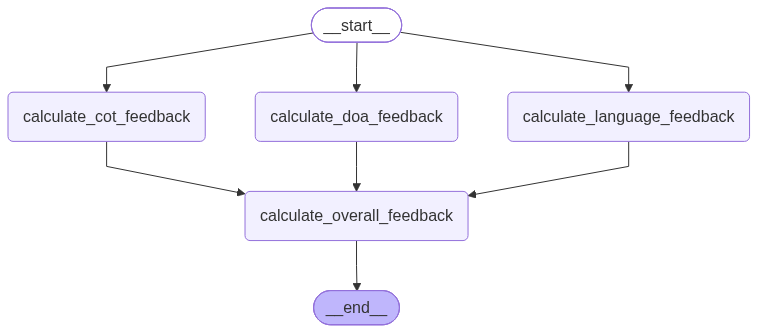

In [49]:
# print the workflow
workflow

In [58]:
# initialise the initial state.
initial_state = {
    'essay_text' : wrong_essay
}

final_state = workflow.invoke(initial_state)

print(final_state)

{'essay_text': "\nArtificial intelligence is everywhere now and it is doing many things but sometimes it is not clear what it is doing and why it is doing. AI is in phones, computers, cars and many other things. People use AI but they maybe don't understand it properly. It is good and bad also because it can do work fast but sometimes it gives wrong things.\n\nAI is used in education because students can ask questions and get answers. But students can also become lazy because they don't want to think themselves. Teachers also use AI but sometimes it make things confusing. AI can help in hospital also because it can find diseases, but doctors still need to see the patient because AI is not always correct.\n\nAI is also changing jobs. Some people say it will take all jobs and some people say it will make new jobs. I think both can happen but it is difficult to say because technology changes very fast. People should learn new things but it is not always easy and everyone does not get same

In [59]:
final_state['individual_scores']

[5, 4, 5]

In [60]:
final_state['average_score']

4.666666666666667

In [57]:
final_state['overall_feedback']

"**Summarized Feedback:**\n\nThe essay effectively provides a well-structured, comprehensive, and clear overview of AI's role in modern life, balancing its benefits and challenges with accessible language and relevant examples. Strengths include its broad analysis across sectors (smartphones, healthcare, education, etc.), ethical considerations, and a strong conclusion emphasizing responsible AI use and human-technology collaboration. However, it could be enhanced by:  \n1. **Depth of Analysis:** Incorporating more specific examples, case studies, or detailed exploration of ethical dilemmas and future implications.  \n2. **Engagement:** Adopting a slightly more engaging tone to captivate readers further.  \n3. **Concrete Solutions:** Suggesting actionable steps or frameworks for responsible AI development and human-AI synergy in the conclusion.  \nOverall, the essay is well-written, informative, and persuasive, but deeper nuance and specificity would elevate its impact."